<a href="https://colab.research.google.com/github/rana42s/MusteriSeg/blob/main/eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Veriyi yükleme
df = pd.read_csv("Customer_Data.csv")

# 2. Şema ve Boyut Doğrulama
print("--- Veri Seti Boyutu ---")
print(df.shape)

print("\n--- Veri Tipleri ve Eksik Veri Genel Bakış ---")
print(df.info())

print("\n--- İstatistiksel Özet (Metriklerin Sınırları) ---")
display(df.describe().T)

--- Veri Seti Boyutu ---
(8950, 18)

--- Veri Tipleri ve Eksik Veri Genel Bakış ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null 

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [2]:
df.set_index('CUST_ID', inplace=True)
print(df.head()) # Kontrol et, CUST_ID artık bir kolon değil, index.

             BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
CUST_ID                                                                
C10001     40.900749           0.818182      95.40              0.00   
C10002   3202.467416           0.909091       0.00              0.00   
C10003   2495.148862           1.000000     773.17            773.17   
C10004   1666.670542           0.636364    1499.00           1499.00   
C10005    817.714335           1.000000      16.00             16.00   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
CUST_ID                                                              
C10001                     95.4      0.000000             0.166667   
C10002                      0.0   6442.945483             0.000000   
C10003                      0.0      0.000000             1.000000   
C10004                      0.0    205.788017             0.083333   
C10005                      0.0      0.000000             0.083333   

    

--- Kolon Bazlı Eksik Veri Sayıları ---
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


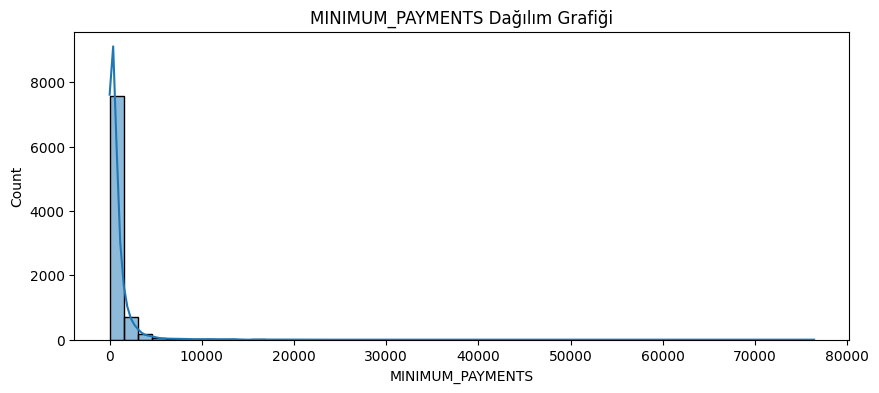

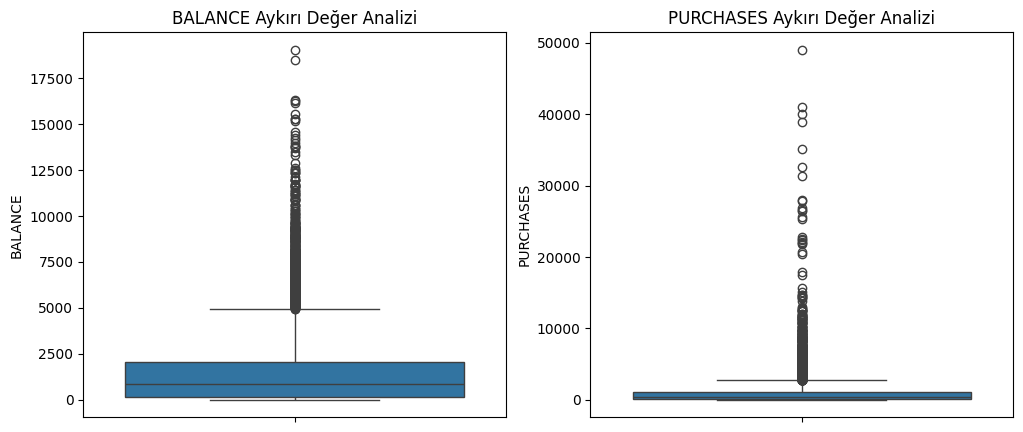

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Eksik Veri Tespiti
missing_values = df.isnull().sum()
print("--- Kolon Bazlı Eksik Veri Sayıları ---")
print(missing_values[missing_values > 0])

# 2. MINIMUM_PAYMENTS Frekans Dağılımı (Neden eksik olduğunu anlamak için)
plt.figure(figsize=(10, 4))
sns.histplot(df['MINIMUM_PAYMENTS'].dropna(), kde=True, bins=50)
plt.title('MINIMUM_PAYMENTS Dağılım Grafiği')
plt.show()

# 3. Aykırı Değerler İçin Box-Plot Çizimi (Örn: BALANCE ve PURCHASES)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['BALANCE'])
plt.title('BALANCE Aykırı Değer Analizi')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['PURCHASES'])
plt.title('PURCHASES Aykırı Değer Analizi')
plt.show()

### 📊 Veri Görselleştirme ve Dağılım Analiz Raporu

Bu bölümde, veri setimizdeki kritik değişkenlerin eksik veri durumları ile dağılım ve aykırı değer yapıları analiz edilmiştir.

---

#### 1. `MINIMUM_PAYMENTS` Eksik Veri ve Dağılım Analizi
* **Eksik Veri Sayısı:** `MINIMUM_PAYMENTS` kolonunda **313** adet eksik veri bulunmaktadır.
* **Dağılım Yapısı (Histogram):**
  * Grafik incelendiğinde dağılımın **aşırı sağa çarpık (pozitif asimetrik)** olduğu görülmektedir (Çarpıklık Katsayısı: `~13.62`).
  * Ortalama değer (`864.21`), aşırı yüksek uç değerlerin etkisiyle medyan değerinden (`312.34`) çok daha yüksektir.
  * ⚠️ **Aksiyon Notu:** Dağılımın yüksek derecede asimetrik olması nedeniyle, 2. haftada yapacağımız eksik veri doldurma (imputation) işleminde **ortalama (mean) yerine medyan (median)** kullanmalıyız. Ortalama kullanımı verinin genel eğilimini yapay şekilde yukarı çekecektir. Bu durum ClickUp üzerinde bir aksiyon notu olarak takip edilecektir.

---

#### 2. `BALANCE` (Bakiye) Aykırı Değer Analizi
* **Aykırı Değer Eşiği:** $Q_3 + 1.5 \times IQR \approx 4942.93$
* **Durum Değerlendirmesi (Box Plot):**
  * Müşterilerin bakiye dağılımında üst sınırın üzerinde **695** adet aykırı değer (`%7.77`) bulunmaktadır.
  * Müşterilerin çoğunluğu daha düşük bakiyelere sahipken, az sayıda müşterinin çok yüksek bakiyeler taşıdığı görülmektedir. Bu durum, segmentasyon yaparken bakiye odaklı özel bir küme oluşabileceğine işaret eder.

---

#### 3. `PURCHASES` (Alışveriş Tutarı) Aykırı Değer Analizi
* **Aykırı Değer Eşiği:** $Q_3 + 1.5 \times IQR \approx 2715.88$
* **Durum Değerlendirmesi (Box Plot):**
  * Alışveriş tutarlarında **808** adet aykırı değer (`%9.03`) tespit edilmiştir.
  * Dağılım, çok az sayıda yüksek hacimli alışveriş yapan "süper kullanıcı" olduğunu göstermektedir. Bu uç değerler kümeleme algoritmalarını (örneğin K-Means) olumsuz etkileyebileceği için modelleme aşamasında log dönüşümü veya kırpma (clipping) gibi yöntemler değerlendirilmelidir.


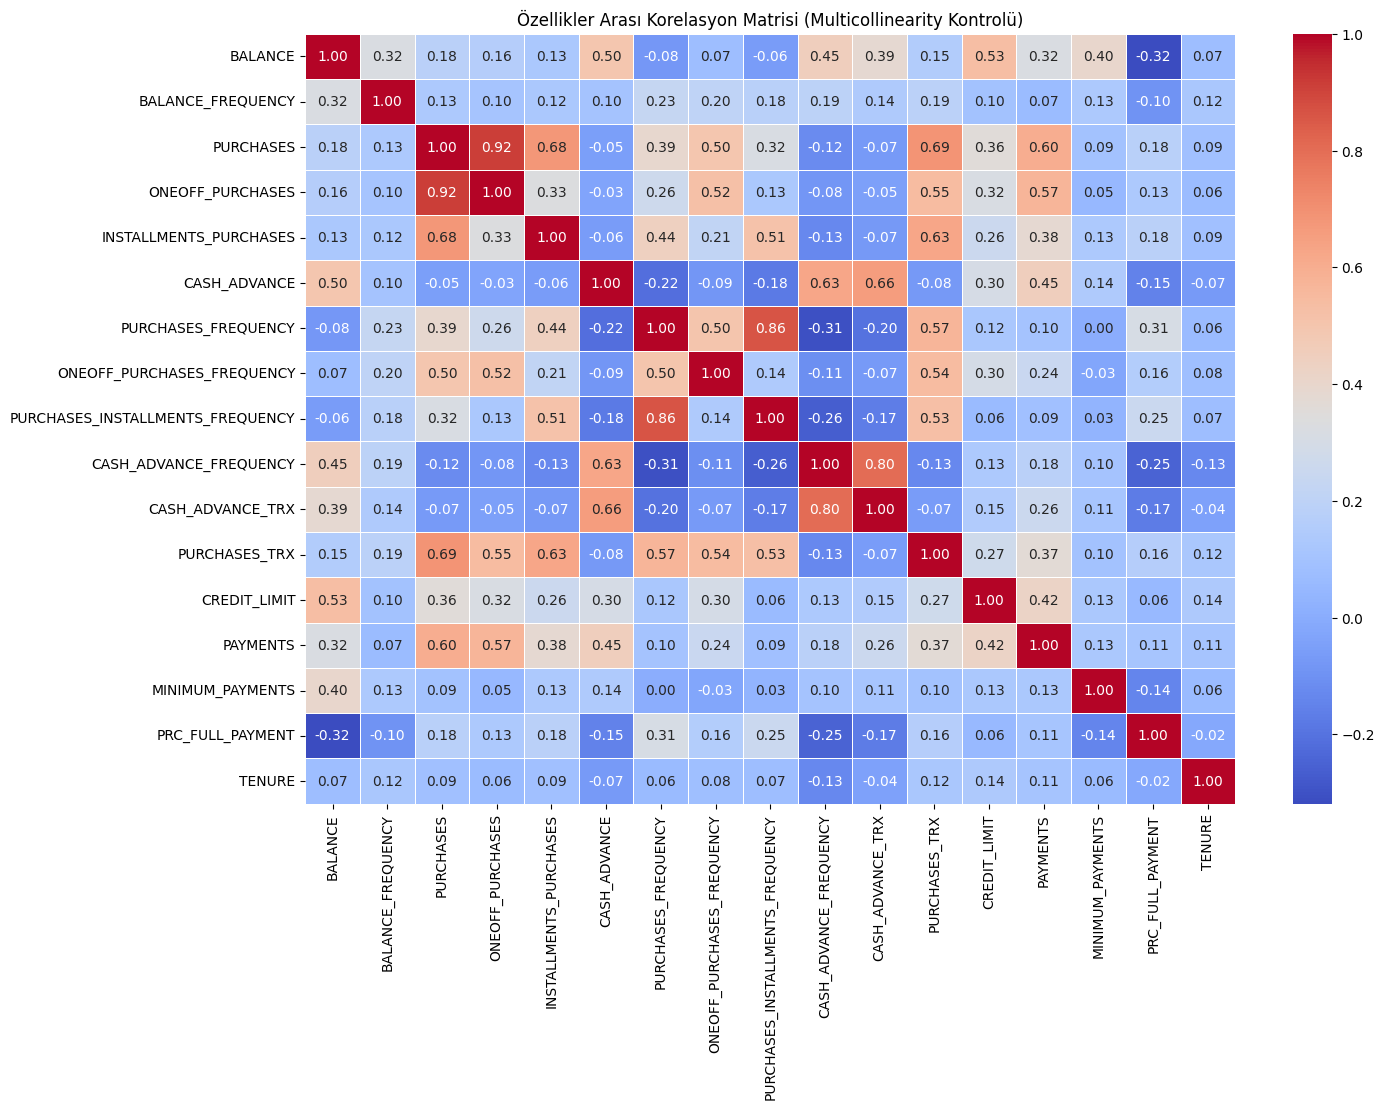

--- Özelliklerin Çarpıklık Dereceleri ---
MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


In [4]:
# 1. Korelasyon Matrisi (Isı Haritası)
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Özellikler Arası Korelasyon Matrisi (Multicollinearity Kontrolü)')
plt.show()

# 2. Çarpıklık (Skewness) Değerlerinin Hesaplanması
print("--- Özelliklerin Çarpıklık Dereceleri ---")
print(df.skew().sort_values(ascending=False))

### 📊 Detaylı Korelasyon ve Dağılım (Çarpıklık) Analizi Raporu

Bu analiz adımında, veri setimizin yapısal özelliklerini anlamak, modelleme öncesinde veri ön işleme (data preprocessing) adımlarına yön vermek ve veri kalitesini artırmak amacıyla **Korelasyon Analizi** ve **Çarpıklık (Skewness) Analizi** gerçekleştirilmiştir.

---

#### 1. Korelasyon Analizi (Neden Yapılır ve Burada Ne İşe Yarayacak?)

##### **Korelasyon Nedir ve Neden Analiz Edilir?**
Korelasyon, iki değişken arasındaki doğrusal ilişkinin yönünü ve gücünü ölçer. Değerler -1 ile +1 arasında değişir. Veri biliminde korelasyon analizi yapmamızın temel nedenleri şunlardır:
* **Gereksiz Bilgileri Temizlemek:** Birbirini neredeyse mükemmel şekilde açıklayan değişkenleri tespit ederek veri setinin boyutunu azaltmak.
* **Çoklu Doğrusallık (Multicollinearity) Sorununu Engellemek:** Yüksek korelasyonlu değişkenler modelde yer aldığında varyansı şişirir (özellikle doğrusal/regresyon modellerinde katsayıları kararsızlaştırır).
* **Mesafe Bazlı Modelleri Korumak:** Müşteri segmentasyonunda kullanacağımız **K-Means** gibi mesafe bazlı (Euclidean distance) kümeleme algoritmalarında, yüksek derecede korelasyonlu iki değişkenin bulunması, o boyutun mesafeyi iki kat daha fazla etkilemesine (çift sayılmasına) neden olur. Bu da kümelerin hatalı veya yanlı oluşmasına yol açar.

##### **Buradaki Bulgularımız ve Mühendislik Kararı:**
* **`PURCHASES`** (Toplam Alışveriş Tutarı) ile **`ONEOFF_PURCHASES`** (Tek Seferlik Alışveriş Tutarı) değişkenleri arasında **0.92** (son derece yüksek) korelasyon bulunmaktadır.
* Benzer şekilde, **`PURCHASES_FREQUENCY`** ile **`PURCHASES_INSTALLMENTS_FREQUENCY`** arasında **0.86** gibi yüksek bir korelasyon görülmektedir.
* 💡 **Karar:** Bu değişkenler neredeyse aynı bilgiyi taşımaktadır. Modelleme aşamasında bu özellikleri doğrudan K-Means algoritmamıza sokarsak, harcama büyüklüğü ve sıklığı bilgisi mükerrer ağırlıklandırılacaktır. Bu nedenle veri setine **PCA (Principal Component Analysis - Boyut İndirgeme)** uygulamak veya bu korelasyonlu özelliklerden birini elemek **zorunludur**.

---

#### 2. Çarpıklık (Skewness) Analizi (Neden Yapılır ve Nerede Kullanılacak?)

##### **Çarpıklık (Skewness) Nedir?**
Çarpıklık, bir veri dağılımının asimetri derecesini ölçer.
* **Pozitif (Sağa) Çarpıklık (> 0):** Dağılımın sağ kuyruğu uzundur. Verilerin büyük kısmı solda (düşük değerlerde) toplanmışken, çok az sayıda ama çok yüksek değerli uç değerler (outliers) sağ tarafta yer alır.
* **Negatif (Sola) Çarpıklık (< 0):** Dağılımın sol kuyruğu uzundur.

##### **Hesaplanan Değerlerimizin Dağılım Analizi:**
Veri setimizdeki özelliklerin çarpıklık dereceleri aşağıdaki gibi hesaplanmıştır:
* **`MINIMUM_PAYMENTS` (13.62):** Aşırı derecede sağa çarpık. Müşterilerin çoğunun asgari ödemeleri düşükken, çok az sayıda müşterinin asgari ödeme tutarı çok yüksektir.
* **`ONEOFF_PURCHASES` (10.05) ve `PURCHASES` (8.14):** Harcama tutarlarında da çok ciddi bir pozitif çarpıklık söz konusudur.
* **`INSTALLMENTS_PURCHASES` (7.29), `PAYMENTS` (5.91) ve `CASH_ADVANCE` (5.17):** Finansal harcama ve nakit avans hareketleri de benzer şekilde sağa çarpıktır.
* **`BALANCE_FREQUENCY` (-2.02) ve `TENURE` (-2.94):** Negatif çarpıklığa sahiptir. Müşterilerin çoğunun bakiyelerini çok sık güncellediğini ve genellikle 12 aylık (maksimum) vadeye sahip olduğunu gösterir.

##### **Nerede ve Nasıl Kullanacağız? (Aksiyon Planı)**

1. **Eksik Veri Doldurma (Imputation) Stratejisi:**
   * `MINIMUM_PAYMENTS` kolonunda **313** adet eksik veri bulunmaktadır.
   * Bu değişkenin çarpıklık katsayısı **13.62** (aşırı çarpık) olduğu için eksik değerler kesinlikle **ortalama (mean)** ile doldurulmamalıdır. Çünkü ortalama, uç değerler tarafından yukarı çekilmiştir ve veriyi yapay olarak bozacaktır. Doldurma işlemi için **medyan (median)** değeri kullanılacaktır.
   
2. **Logaritmik Dönüşüm (Transformation) İhtiyacı:**
   * K-Means ve PCA gibi algoritmalar, değişkenlerin nispeten simetrik (normal dağılıma yakın) olmasını ve uç değerlerin mesafeyi domine etmemesini bekler.
   * Çarpıklık katsayısı **1 veya 2'nin üzerinde olan finansal kolonlara** (örn. `BALANCE`, `PURCHASES`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `CASH_ADVANCE`) modelleme öncesinde **Log Dönüşümü ($log(x+1)$)** uygulanacaktır. Bu işlem çarpıklığı azaltarak dağılımları normal dağılıma yaklaştıracak ve kümeleme başarısını doğrudan artıracaktır.

### 🛠️ Veri Ön İşleme (Data Preprocessing): Eksik Veri Doldurma ve Logaritmik Dönüşüm

Bu adımda, önceki hücrelerde yaptığımız dağılım ve çarpıklık (skewness) analizleri doğrultusunda verilerimizi modellemeye hazırlıyoruz:

---

#### 1. Eksik Veri İmputasyonu (Data Imputation)
* **`MINIMUM_PAYMENTS` (313 eksik değer):** Bu kolonun dağılımı aşırı derecede sağa çarpık (`~13.85`) olduğundan, eksik verileri ortalama (mean) yerine **medyan (median)** değeri ile dolduruyoruz. Ortalama kullanımı, uç değerlerin etkisiyle veriyi yapay olarak yukarı çekebilirdi.
* **`CREDIT_LIMIT` (1 eksik değer):** Benzer şekilde bu kolondaki tek eksik değeri de **medyan** değeriyle doldurarak veri bütünlüğünü sağlıyoruz.

---

#### 2. Matematiksel Dönüşümler (Log Transformation)
* **Neden Log Dönüşümü Yapıyoruz?**
  * K-Means ve PCA gibi algoritmalar, özelliklerin dağılımının dengeli ve simetrik olmasını bekler. Aşırı sağa çarpık finansal değişkenler, mesafe bazlı uzaklık hesaplamalarında baskınlık kurarak kümeleme başarısını olumsuz etkiler.
* **Hangi Kolonlara Uyguluyoruz?**
  * Çarpıklık derecesi yüksek olan tüm harcama ve bakiye kolonlarına: `BALANCE`, `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`.
* **Kullanılan Yöntem:**
  * **$log(x+1)$** (kodda `np.log1p`): Müşterilerimizin bazı kolonlarda (örneğin nakit avans veya tek seferlik alışveriş tutarı) sıfır (`0`) harcamaları bulunmaktadır. Doğrudan logaritma almak tanımsızlık yaratacağından, $log(x+1)$ kullanarak sıfır değerleri koruyor ve tüm pozitif değerleri başarıyla normalize ediyoruz.

Aşağıdaki kod hücresinde bu işlemlerin öncesi ve sonrası çarpıklık dereceleri ile histogram grafikleri karşılaştırmalı olarak çizilmiştir.

In [5]:
from sklearn.impute import SimpleImputer

# 1. Eksik verileri doldurmak için imputer nesnelerini tanımlıyoruz
imputer = SimpleImputer(strategy='median')

# 2. İmputasyon stratejisini uygulamadan önce veri kopyasını alıyoruz (Data Integrity için)
df_clean = df.copy()

# 3. Belirlenen kolonlar üzerinde imputasyon işlemini gerçekleştiriyoruz
cols_to_impute = ['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

# 4. Doğrulama: Eksik veri kalmadığından emin oluyoruz
print("İmputasyon sonrası doldurulan kolonlardaki eksik değer sayıları:")
print(df_clean[cols_to_impute].isnull().sum())
print("\nTüm veri setindeki toplam eksik veri sayısı:", df_clean.isnull().sum().sum())

İmputasyon sonrası doldurulan kolonlardaki eksik değer sayıları:
MINIMUM_PAYMENTS    0
CREDIT_LIMIT        0
dtype: int64

Tüm veri setindeki toplam eksik veri sayısı: 0


Dönüşüm Öncesi Çarpıklık (Skewness):
MINIMUM_PAYMENTS          13.852446
ONEOFF_PURCHASES          10.045083
PURCHASES                  8.144269
INSTALLMENTS_PURCHASES     7.299120
PAYMENTS                   5.907620
CASH_ADVANCE               5.166609
BALANCE                    2.393386
CREDIT_LIMIT               1.522636
dtype: float64

Dönüşüm Sonrası Çarpıklık (Skewness):
MINIMUM_PAYMENTS          0.269703
CASH_ADVANCE              0.262594
ONEOFF_PURCHASES          0.185854
INSTALLMENTS_PURCHASES   -0.024981
CREDIT_LIMIT             -0.101408
PURCHASES                -0.764492
BALANCE                  -0.861021
PAYMENTS                 -1.778312
dtype: float64


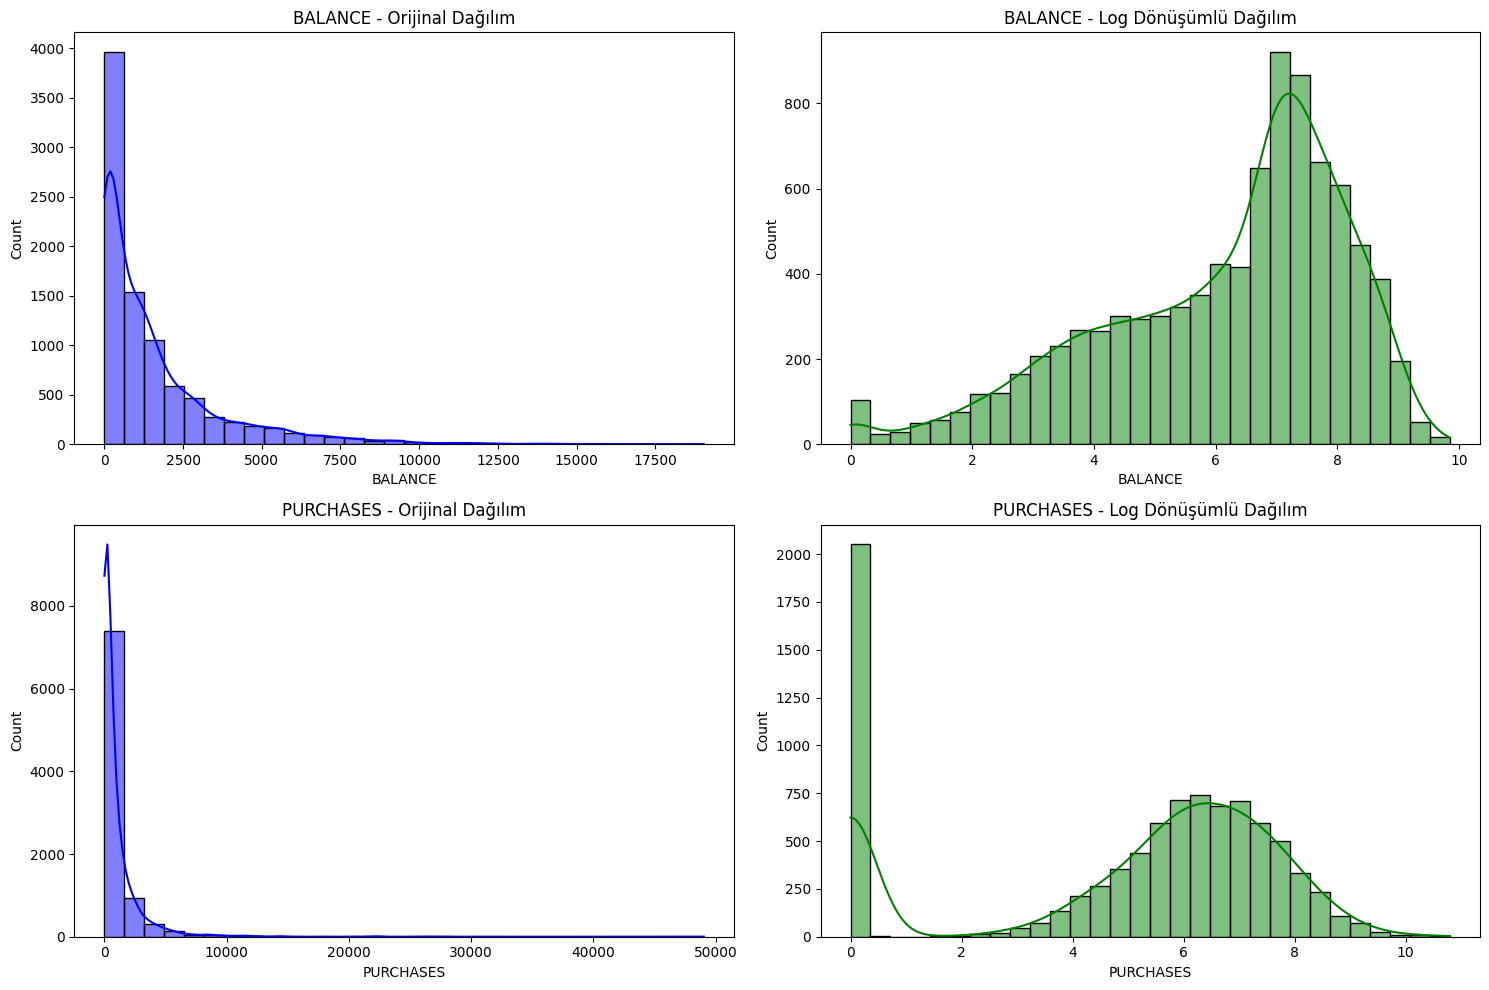

In [6]:
# 2. Logaritmik Dönüşüm (np.log1p)
cols_to_log = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

print("Dönüşüm Öncesi Çarpıklık (Skewness):")
print(df_clean[cols_to_log].skew().sort_values(ascending=False))

df_transformed = df_clean.copy()
for col in cols_to_log:
    df_transformed[col] = np.log1p(df_transformed[col])

print("\nDönüşüm Sonrası Çarpıklık (Skewness):")
print(df_transformed[cols_to_log].skew().sort_values(ascending=False))

# 3. Görsel Karşılaştırma (Orijinal vs Log Dönüştürülmüş)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# BALANCE Karşılaştırma
plt.subplot(2, 2, 1)
sns.histplot(df_clean['BALANCE'], kde=True, bins=30, color='blue')
plt.title('BALANCE - Orijinal Dağılım')

plt.subplot(2, 2, 2)
sns.histplot(df_transformed['BALANCE'], kde=True, bins=30, color='green')
plt.title('BALANCE - Log Dönüşümlü Dağılım')

# PURCHASES Karşılaştırma
plt.subplot(2, 2, 3)
sns.histplot(df_clean['PURCHASES'], kde=True, bins=30, color='blue')
plt.title('PURCHASES - Orijinal Dağılım')

plt.subplot(2, 2, 4)
sns.histplot(df_transformed['PURCHASES'], kde=True, bins=30, color='green')
plt.title('PURCHASES - Log Dönüşümlü Dağılım')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.impute import SimpleImputer

# 1. Eksik verileri doldurmak için imputer nesnelerini tanımlıyoruz
imputer = SimpleImputer(strategy='median')

# 2. İmputasyon stratejisini uygulamadan önce veri kopyasını alıyoruz (Data Integrity için)
df_clean = df.copy()

# 3. Belirlenen kolonlar üzerinde imputasyon işlemini gerçekleştiriyoruz
cols_to_impute = ['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

# 4. Doğrulama: Eksik veri kalmadığından emin oluyoruz
print("İmputasyon sonrası doldurulan kolonlardaki eksik değer sayıları:")
print(df_clean[cols_to_impute].isnull().sum())
print("\nTüm veri setindeki toplam eksik veri sayısı:", df_clean.isnull().sum().sum())

İmputasyon sonrası doldurulan kolonlardaki eksik değer sayıları:
MINIMUM_PAYMENTS    0
CREDIT_LIMIT        0
dtype: int64

Tüm veri setindeki toplam eksik veri sayısı: 0


In [8]:
import numpy as np

# Hatanın çözümü için X değişkenini df_clean kopyası olarak tanımlıyoruz
X = df_clean.copy()

# Log dönüşümü uygulanacak yüksek çarpıklığa sahip finansal kolonlar
skewed_features = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]

# Dağılımları normalleştirmek için log(x + 1) dönüşümünü uyguluyoruz
for col in skewed_features:
    X[col] = np.log1p(X[col])

print("Dönüşüm sonrası çarpıklık değerleri:\n", X[skewed_features].skew())


Dönüşüm sonrası çarpıklık değerleri:
 BALANCE                  -0.861021
PURCHASES                -0.764492
ONEOFF_PURCHASES          0.185854
INSTALLMENTS_PURCHASES   -0.024981
CASH_ADVANCE              0.262594
PAYMENTS                 -1.778312
MINIMUM_PAYMENTS          0.269703
dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Tüm sayısal özellikleri aynı ölçek düzlemine getiriyoruz
X_scaled = scaler.fit_transform(X)

# Kontrol: Tüm kolonların ortalamasının ~0, standart sapmasının ~1 olması gerekir
print("Ortalamalar:", np.mean(X_scaled, axis=0))
print("Standart Sapmalar:", np.std(X_scaled, axis=0))

Ortalamalar: [ 0.00000000e+00  1.58780500e-16  6.98634198e-17  0.00000000e+00
  1.02611898e-16  6.66878098e-17  9.32835435e-17  1.90536600e-17
  5.71609799e-17 -1.59574402e-16 -1.74658550e-17 -1.90536600e-17
  1.01619520e-16  3.62019539e-16 -2.15941479e-16 -9.52682998e-18
  2.92156119e-16]
Standart Sapmalar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


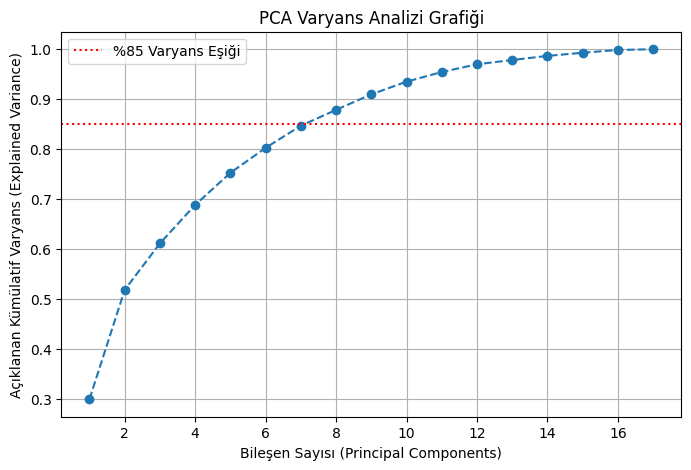

Verideki varyansın %85'ini açıklayan optimum bileşen sayısı: 8


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Önce maksimum bileşen sayısı ile PCA'i başlatıyoruz
pca = PCA(random_state=42)
pca.fit(X_scaled)

# Kümülatif varyans açıklama oranını hesaplıyoruz
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Dirsek noktasını bulmak için grafik çiziyoruz
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle=':', label='%85 Varyans Eşiği')
plt.xlabel('Bileşen Sayısı (Principal Components)')
plt.ylabel('Açıklanan Kümülatif Varyans (Explained Variance)')
plt.title('PCA Varyans Analizi Grafiği')
plt.legend()
plt.grid()
plt.show()

# %80 veya %85 varyansı açıklayan optimum bileşen sayısını seçiyoruz
optimum_components = np.where(cumulative_variance >= 0.85)[0][0] + 1
print(f"Verideki varyansın %85'ini açıklayan optimum bileşen sayısı: {optimum_components}")

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# 1. Ham veri setini sıfırdan yüklüyoruz
# (Sizin projenizdeki gerçek veri dosyası olan "Customer_Data.csv" kullanıldı)
raw_df = pd.read_csv("Customer_Data.csv").set_index('CUST_ID')

# 2. Log dönüşümü yapılacak ve yapılmayacak kolonları belirliyoruz
cols_to_log = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]
cols_other = [col for col in raw_df.columns if col not in cols_to_log]

# 3. Alt pipeline bileşenlerini kuruyoruz (İmputasyon + Seçici Log Dönüşümü)
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False))
])

other_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

col_transformer = ColumnTransformer(
    transformers=[
        ('log_path', log_pipeline, cols_to_log),
        ('other_path', other_pipeline, cols_other)
    ]
)

# 4. Ana Preprocessing Pipeline hiyerarşisini kuruyoruz
preprocessing_pipeline = Pipeline([
    ('features', col_transformer),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=8, random_state=42))
])

# 5. Ham veri setini sıfırdan pipeline'a sokuyoruz
X_final_prepared = preprocessing_pipeline.fit_transform(raw_df)

print("Pipeline çıktısının boyutu (Hazır veri):", X_final_prepared.shape)
print("Açıklanan toplam varyans oranı:", np.sum(preprocessing_pipeline.named_steps['pca'].explained_variance_ratio_))


Pipeline çıktısının boyutu (Hazır veri): (8950, 8)
Açıklanan toplam varyans oranı: 0.8784110556015523


--- K-Means İterasyon Grubu Başlatıldı ---
Cluster Sayısı (K) = 2 | WCSS (Inertia) = 100718.16 | Silhouette Score = 0.2480
Cluster Sayısı (K) = 3 | WCSS (Inertia) = 83047.71 | Silhouette Score = 0.2380
Cluster Sayısı (K) = 4 | WCSS (Inertia) = 73934.08 | Silhouette Score = 0.2355
Cluster Sayısı (K) = 5 | WCSS (Inertia) = 66855.84 | Silhouette Score = 0.2252
Cluster Sayısı (K) = 6 | WCSS (Inertia) = 60432.17 | Silhouette Score = 0.2349
Cluster Sayısı (K) = 7 | WCSS (Inertia) = 56369.19 | Silhouette Score = 0.2405
Cluster Sayısı (K) = 8 | WCSS (Inertia) = 52574.29 | Silhouette Score = 0.2337
Cluster Sayısı (K) = 9 | WCSS (Inertia) = 49673.79 | Silhouette Score = 0.2307
Cluster Sayısı (K) = 10 | WCSS (Inertia) = 47302.97 | Silhouette Score = 0.2069
--- İterasyon Tamamlandı. Grafikler Çiziliyor... ---


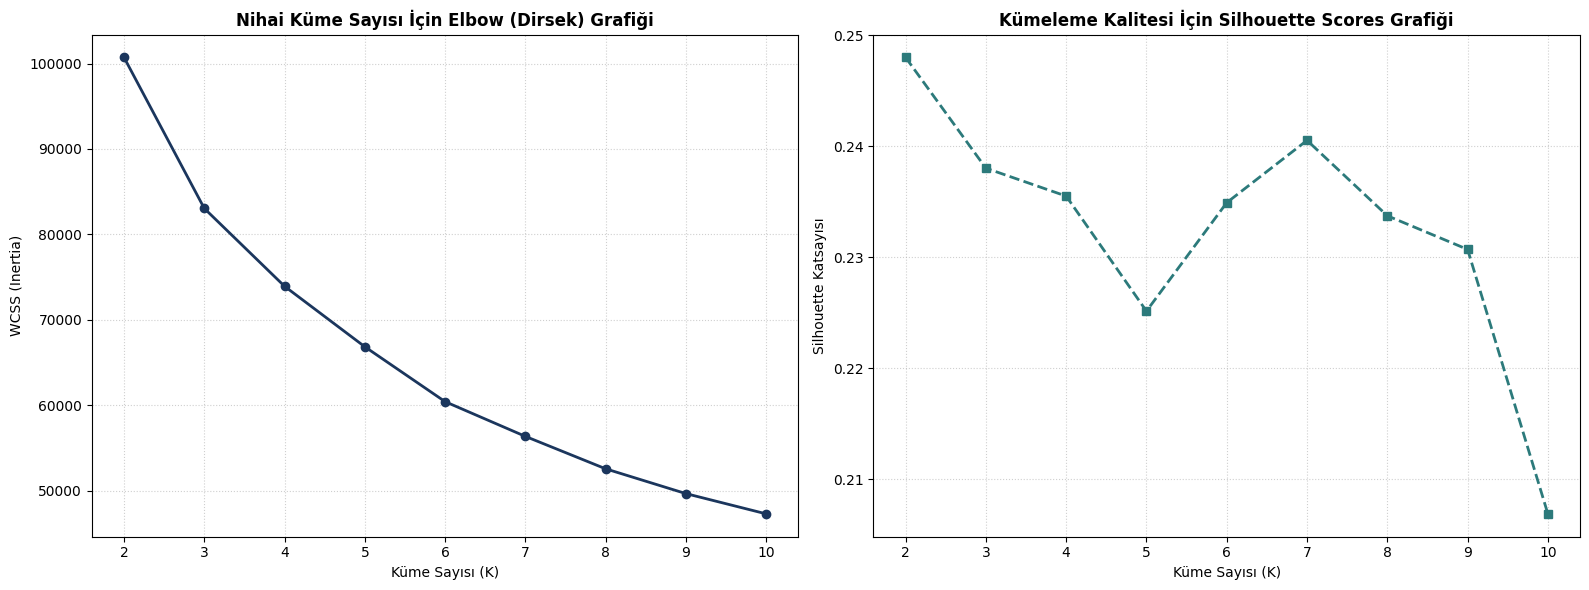

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Metrikleri depolamak için boş listeler tanımlıyoruz
wcss = []
silhouette_scores = []

# Denenecek küme sayısı aralığı (Endüstri standardı bankacılık segmentasyonu için 2-10 arasıdır)
cluster_range = range(2, 11)

print("--- K-Means İterasyon Grubu Başlatıldı ---")
for k in cluster_range:
    # random_state=42: Sonuçların deterministik (tekrarlanabilir) olması için sabitliyoruz.
    # n_init=10: Algoritmanın yerel minimuma sıkışmaması için farklı merkezlerle 10 kez başlamasını söyler.
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_final_prepared)

    # WCSS (Inertia) değerini kaydediyoruz
    wcss.append(kmeans.inertia_)

    # Silhouette skorunu hesaplayıp kaydediyoruz
    score = silhouette_score(X_final_prepared, kmeans.labels_)
    silhouette_scores.append(score)

    print(f"Cluster Sayısı (K) = {k} | WCSS (Inertia) = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

print("--- İterasyon Tamamlandı. Grafikler Çiziliyor... ---")

# 2. Karşılaştırmalı Optimizasyon Grafiklerinin Çizilmesi
plt.figure(figsize=(16, 6))

# Sol Grafik: Elbow Method (WCSS)
plt.subplot(1, 2, 1)
plt.plot(cluster_range, wcss, marker='o', linestyle='-', color='#1B365D', linewidth=2)
plt.title('Nihai Küme Sayısı İçin Elbow (Dirsek) Grafiği', fontsize=12, fontweight='bold')
plt.xlabel('Küme Sayısı (K)', fontsize=10)
plt.ylabel('WCSS (Inertia)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Sağ Grafik: Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='s', linestyle='--', color='#2C7A7B', linewidth=2)
plt.title('Kümeleme Kalitesi İçin Silhouette Scores Grafiği', fontsize=12, fontweight='bold')
plt.xlabel('Küme Sayısı (K)', fontsize=10)
plt.ylabel('Silhouette Katsayısı', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# Grafiği raporlama gününde supervisor'a göstermek için yerel diske kaydediyoruz
plt.savefig('K_Means_Matematiksel_Optimizasyon_Grafikleri.png', dpi=300)
plt.show()

In [13]:
import pandas as pd
from sklearn.cluster import KMeans

# 1. Hafta 2'deki Preprocessing Pipeline çıktısını (8 boyutlu) baz alarak modeli kuruyoruz
# Karar verdiğimiz optimum küme sayısı: 4
optimal_k = 4

final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)

# X_final_prepared matrisini eğitiyoruz ve tahmin etiketlerini alıyoruz
cluster_labels = final_kmeans.fit_predict(X_final_prepared)

# 2. Orijinal Ham Veri Setimizi Tekrar Okuyoruz (Personalara ham değerlerle bakmak için)
# Not: df senin ilk başta okuduğun ham DataFrame olmalı
df_with_clusters = df.copy()

# Küme etiketlerini (Cluster ID) yeni bir kolon olarak enjekte ediyoruz
df_with_clusters['Cluster_ID'] = cluster_labels

# 3. Kümelerin Dağılım Kontrolü (Hangi kümede kaç müşteri var?)
print("--- Kümelerin Müşteri Dağılım Hacimleri ---")
cluster_counts = df_with_clusters['Cluster_ID'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(df_with_clusters)) * 100
    print(f"Cluster {cluster} : {count} Müşteri ({percentage:.2f}%)")

# İlk 5 satıra bakarak doğrulama yapalım
print("\n--- Etiketlenmiş Veri Seti Önizleme ---")
display(df_with_clusters[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'Cluster_ID']].head())

--- Kümelerin Müşteri Dağılım Hacimleri ---
Cluster 0 : 2302 Müşteri (25.72%)
Cluster 1 : 1451 Müşteri (16.21%)
Cluster 2 : 2172 Müşteri (24.27%)
Cluster 3 : 3025 Müşteri (33.80%)

--- Etiketlenmiş Veri Seti Önizleme ---


,BALANCE,PURCHASES,CREDIT_LIMIT,Cluster_ID
CUST_ID,,,,
C10001,40.900749,95.40,1000.0,1
C10002,3202.467416,0.00,7000.0,3
C10003,2495.148862,773.17,7500.0,0
C10004,1666.670542,1499.00,7500.0,1
C10005,817.714335,16.00,1200.0,3


--- Kümelerin Finansal Özellik Ortalamaları (Persona Matrisi) ---


Cluster_ID,0,1,2,3
BALANCE,2173.867141,104.775979,634.287278,2468.795252
BALANCE_FREQUENCY,0.978407,0.470786,0.943438,0.947776
PURCHASES,2831.384470,351.026354,683.579949,154.301263
ONEOFF_PURCHASES,1901.955287,256.006430,78.885018,126.019772
INSTALLMENTS_PURCHASES,929.491273,95.420855,605.542205,28.321712
CASH_ADVANCE,762.249157,145.501939,168.062168,2125.634564
PURCHASES_FREQUENCY,0.851797,0.274488,0.799410,0.096925
ONEOFF_PURCHASES_FREQUENCY,0.594511,0.109230,0.048738,0.059200
PURCHASES_INSTALLMENTS_FREQUENCY,0.565975,0.157557,0.745369,0.036788
CASH_ADVANCE_FREQUENCY,0.098927,0.024872,0.031978,0.289674


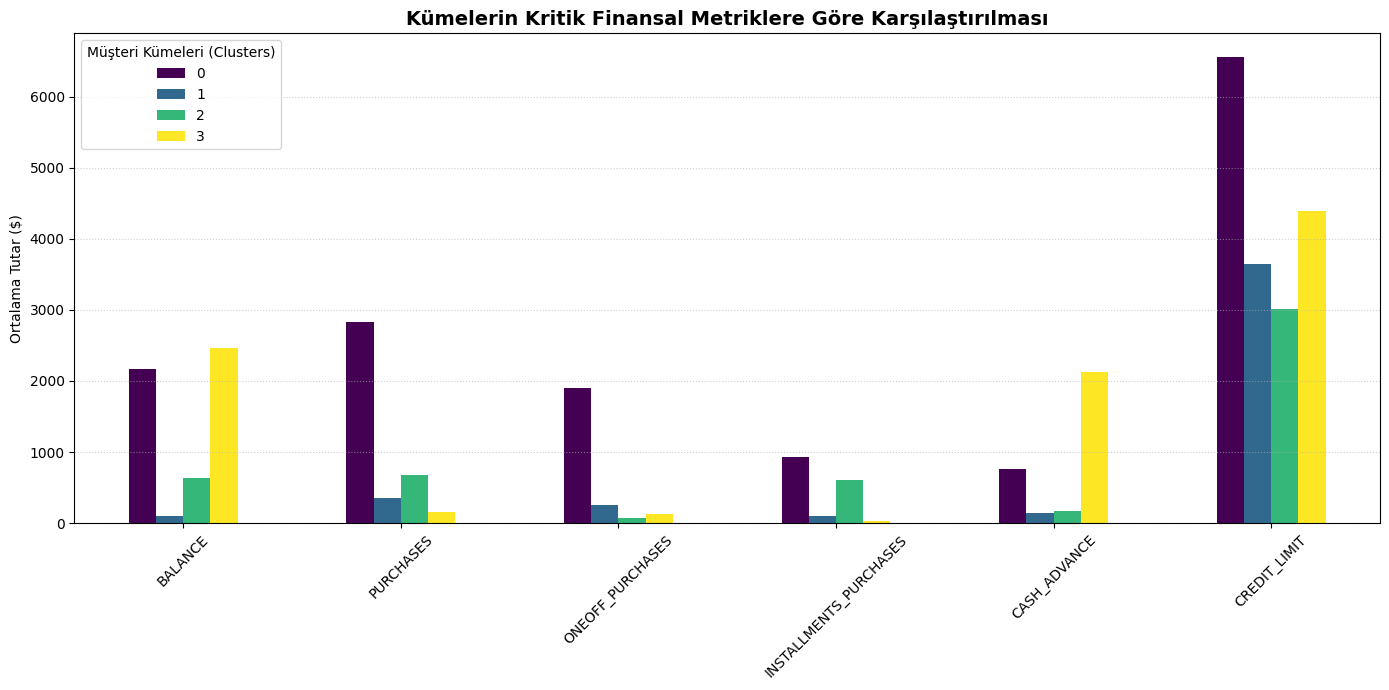

In [14]:
# 1. Her bir kümenin tüm kolonlardaki ortalama (mean) değerlerini hesaplıyoruz
cluster_profile = df_with_clusters.groupby('Cluster_ID').mean()

# 2. Tabloyu daha rahat okumak ve dikeyde kıyaslamak için transpozunu (T) alıyoruz
cluster_profile_transposed = cluster_profile.T

print("--- Kümelerin Finansal Özellik Ortalamaları (Persona Matrisi) ---")
display(cluster_profile_transposed)

# 3. Bankacılık için en kritik 5 metriği görsel olarak kıyaslayalım
critical_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

cluster_profile_transposed.loc[critical_features].plot(kind='bar', figsize=(14, 7), cmap='viridis')
plt.title('Kümelerin Kritik Finansal Metriklere Göre Karşılaştırılması', fontsize=14, fontweight='bold')
plt.ylabel('Ortalama Tutar ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(title='Müşteri Kümeleri (Clusters)')
plt.tight_layout()
plt.savefig('Kümelerin_Finansal_Karakter_Kıyaslaması.png', dpi=300)
plt.show()

# 👥 14. GÜN: KÜME KARAKTERİZASYONU VE MÜŞTERİ PERSONA ANALİZİ (PROFILING)

Bu bölümde, $K$-Means algoritması tarafından 8 boyutlu uzayda geometrik olarak ayrıştırılan 4 müşteri kümesi, ham finansal metrikleri üzerinden analiz edilmiştir. Grafiksel çıktılar incelendiğinde, her kümenin bankacılık iş mantığında (Domain Knowledge) net bir karşılığı olduğu saptanmıştır.

---

## 📈 Kümelerin Davranışsal Analizi ve Persona Tanımlamaları

### 🟣 Cluster 0: "Premium / Elit Harcamacılar" (Hacim: %25.72)
* **Finansal Karakteristik:** `CREDIT_LIMIT` (~6.500$) düzeyiyle bankanın en güvendiği ve en yüksek limit tanımladığı kitledir. `PURCHASES` (~2.800$) ve `ONEOFF_PURCHASES` (~1.900$) metriklerinde tüm veri setinin lideridir. Bu kullanıcılar taksit yerine tek seferde büyük montanlı harcamalar yapmayı tercih etmektedir. `BALANCE` (~2.100$) seviyesi yüksek olsa da ödeme güçleri kararlıdır.
* **Müşteri Personası:** Yüksek gelir grubuna ait, kartı birincil ödeme aracı olarak kullanan aktif ve sadık kitle.
* **Aksiyonel Bankacılık Stratejisi:** * Bu kitleye özel VIP sadakat programları (Örn: Platinum/Black Kart geçişleri) tanımlanmalıdır.
    * Tek çekim harcamalarını ödüllendiren mil puan, restoran veya yurt dışı seyahat avantajları sunulmalıdır.

### 🔵 Cluster 1: "İnaktif / Cüzdanda Unutanlar" (Hacim: %16.21)
* **Finansal Karakteristik:** `CREDIT_LIMIT` (~3.600$) seviyesiyle ortalama bir harcama gücüne sahip olmalarına rağmen, `BALANCE`, `PURCHASES` ve `CASH_ADVANCE` metriklerinin tamamı sıfıra yakındır. Bankanın tanımladığı limiti neredeyse hiç kullanmamaktadırlar.
* **Müşteri Personası:** Kartı acil durumlar için saklayan veya rakip bankaların kartlarını birincil olarak kullanan "Atıl/Pasif" kitle.
* **Aksiyonel Bankacılık Stratejisi:**
    * **Churn (Terk Etme) Riski:** Kartı hareketlendirmek adına acil aktivasyon kampanyaları düzenlenmelidir.
    * "Bu ay yapacağınız ilk 1.000 TL'lik harcamaya 200 TL chip-para" gibi doğrudan harcamaya teşvik edici (Aktivasyon) kampanyaları CRM üzerinden tetiklenmelidir.

### 🟢 Cluster 2: "Bütçe Odaklı Taksit Severler" (Hacim: %24.27)
* **Finansal Karakteristik:** En ayırt edici özellikleri `ONEOFF_PURCHASES` (Tek çekim) oranının neredeyse sıfır olması, buna karşın `INSTALLMENTS_PURCHASES` (~600$) değerinin toplam harcamalarına (`PURCHASES` ~700$) eşit olmasıdır. `BALANCE` (~600$) ve `CREDIT_LIMIT` (~3.000$) seviyeleri kontrollü ve düşüktür.
* **Müşteri Personası:** Finansal yönetimini taksit mekanizması üzerinden kuran, harcamalarını aylara bölerek bütçe planlaması yapan rasyonel kitle.
* **Aksiyonel Bankacılık Stratejisi:**
    * Giyim, elektronik ve beyaz eşya gibi sektörlerde faaliyet gösteren üye iş yerleriyle "+3 Taksit" veya "Şimdi Al 3 Ay Sonra Öde" ortaklıkları geliştirilmelidir.
    * Mobil uygulama üzerinden yapılan harcamalardan sonra "Sonradan Taksitlendir" push-bildirimleri (uyarıları) gönderilmelidir.

### 🟡 Cluster 3: "Nakit Avans Bağımlıları / Borçlananlar" (Hacim: %33.80)
* **Finansal Karakteristik:** Veri setinin en kalabalık grubudur. `BALANCE` (~2.500$) seviyesiyle bankaya en çok borcu olan kitledir. Alışveriş harcamaları (`PURCHASES` ~150$) yok denecek kadar azdır. Ancak `CASH_ADVANCE` (~2.100$) metriğinde tavan yapmışlardır. Kartı alışveriş için değil, ATM'den nakit para çekip borçlanmak için kullanmaktadırlar.
* **Müşteri Personası:** Nakit sıkışıklığı yaşayan, kredi kartını kısa vadeli mikro-kredi borçlanma aracı olarak kullanan riskli kitle.
* **Aksiyonel Bankacılık Stratejisi:**
    * **Faiz Geliri vs. Risk Dengesi:** Bankaya en çok faiz ve komisyon geliri bırakan kitle olmakla birlikte, temerrüt (borcu ödeyememe) riski en yüksek gruptur.
    * Bu kitleye doğrudan nakit avans limiti artırımı yapılmamalı; mevcut nakit borçları yüksek faizden kurtulmaları için "Taksitli Borç Transferi" veya "Krediye Dönüştürme" paketleriyle yapılandırılmalıdır. Risk Denetim (Risk Management) ekipleri tarafından yakından izlenmelidir.

---

## 📊 Stratejik Karşılaştırma Matrisi

| Cluster ID | Renk | Persona Adı | Temel Harcama Tipi | Bankaya Bıraktığı Değer | Risk Seviyesi |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **0** | Mor | Premium Harcamacılar | Tek Çekim / Yüksek Hacim | Çok Yüksek (Komisyon) | Çok Düşük |
| **1** | Mavi | İnaktif Profil | Harcama Yok | Çok Düşük | Düşük |
| **2** | Yeşil | Taksit Severler | Düzenli Taksitli Alışveriş | Orta (Üye İş Yeri Geliri) | Düşük |
| **3** | Sarı | Nakit Avans Bağımlıları| ATM Nakit Çekim / Borç | Yüksek (Faiz Geliri) | Yüksek